## Ejercicio 1.1: Diagrama de Caja y Límites de Valores Atípicos

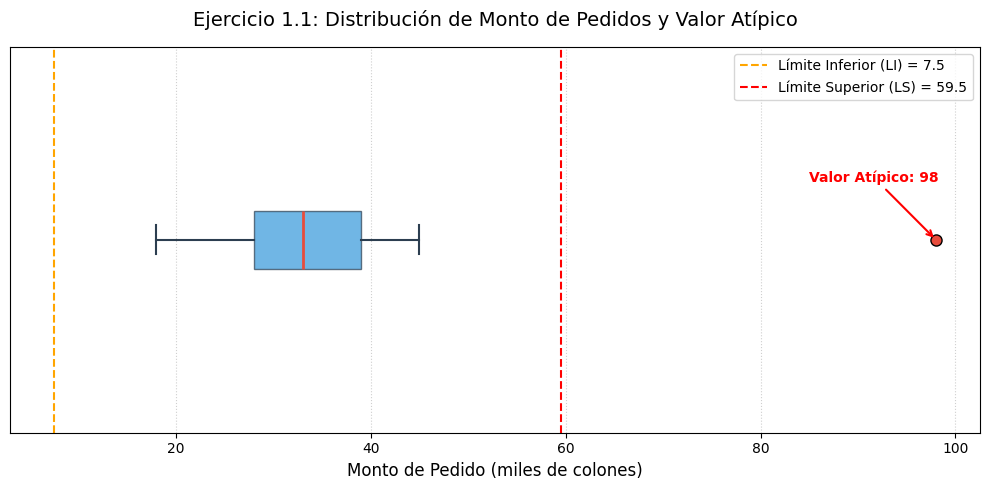

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del ejercicio 1.1
datos = [18, 22, 25, 27, 29, 30, 31, 33, 35, 36, 38, 40, 42, 45, 98]

q1 = 27
mediana = 33
q3 = 40
li = 7.5
ls = 59.5

fig, ax = plt.subplots(figsize=(10, 5))

# Graficar Boxplot
bp = ax.boxplot(
    datos,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#3498db", color="#2c3e50", alpha=0.7),
    whiskerprops=dict(color="#2c3e50", linewidth=1.5),
    capprops=dict(color="#2c3e50", linewidth=1.5),
    medianprops=dict(color="#e74c3c", linewidth=2),
    flierprops=dict(
        marker="o", markerfacecolor="#e74c3c", markersize=8, linestyle="none"
    ),
)

# Líneas auxiliares
ax.axvline(
    li,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Límite Inferior (LI) = {li}",
)
ax.axvline(
    ls,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Límite Superior (LS) = {ls}",
)

# Personalización
ax.set_title(
    "Ejercicio 1.1: Distribución de Monto de Pedidos y Valor Atípico",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Monto de Pedido (miles de colones)", fontsize=12)
ax.set_yticks([])
ax.legend(loc="upper right")
ax.grid(axis="x", linestyle=":", alpha=0.6)

# Anotaciones
ax.annotate(
    "Valor Atípico: 98",
    xy=(98, 1),
    xytext=(85, 1.15),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=10,
    color="red",
    weight="bold",
)

plt.tight_layout()
plt.show()

## Ejercicio 1.2: Boxplot Reconstruido

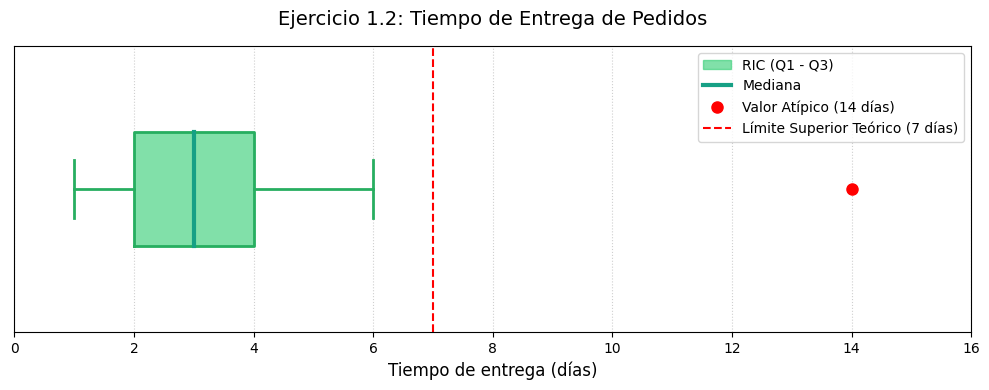

In [2]:
import matplotlib.pyplot as plt

# Reconstrucción del Boxplot con los datos estadísticos clave
q1, mediana, q3 = 2, 3, 4
whisker_min, whisker_max = 1, 6
outlier = 14

fig, ax = plt.subplots(figsize=(10, 4))

# Caja central (Q1 a Q3)
ax.fill_betweenx(
    [0.8, 1.2], q1, q3, color="#2ecc71", alpha=0.6, label="RIC (Q1 - Q3)"
)
ax.plot([q1, q1, q3, q3, q1], [0.8, 1.2, 1.2, 0.8, 0.8], color="#27ae60", lw=2)

# Línea de Mediana
ax.plot([mediana, mediana], [0.8, 1.2], color="#16a085", lw=3, label="Mediana")

# Bigotes (Whiskers)
ax.plot([whisker_min, q1], [1, 1], color="#27ae60", lw=2)
ax.plot([q3, whisker_max], [1, 1], color="#27ae60", lw=2)
ax.plot([whisker_min, whisker_min], [0.9, 1.1], color="#27ae60", lw=2)
ax.plot([whisker_max, whisker_max], [0.9, 1.1], color="#27ae60", lw=2)

# Valor Atípico
ax.plot(
    outlier,
    1,
    "ro",
    markersize=8,
    label="Valor Atípico (14 días)",
    zorder=5,
)

# Límite Superior Teórico (LS = 7)
ax.axvline(
    7,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Límite Superior Teórico (7 días)",
)

# Configuración del gráfico
ax.set_ylim(0.5, 1.5)
ax.set_xlim(0, 16)
ax.set_xlabel("Tiempo de entrega (días)", fontsize=12)
ax.set_title("Ejercicio 1.2: Tiempo de Entrega de Pedidos", fontsize=14, pad=15)
ax.set_yticks([])
ax.legend(loc="upper right")
ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## Ejercicio 1.3: Comparación de Dispersión y Coeficiente de Variación

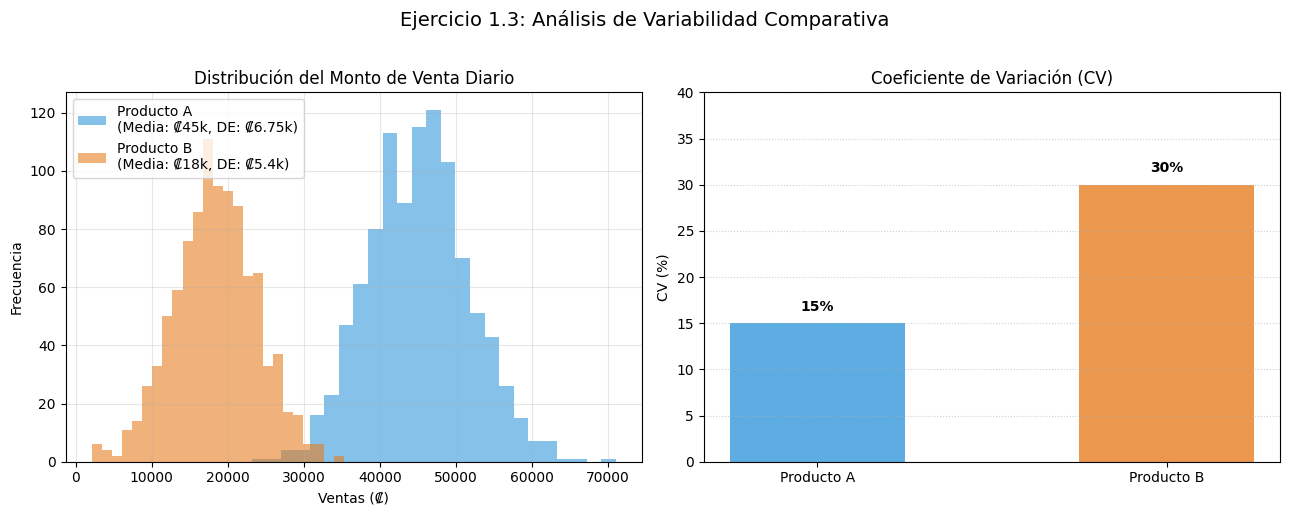

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros del ejercicio 1.3
mean_a, std_a = 45000, 6750
mean_b, std_b = 18000, 5400

# Simulación de distribuciones normales asociadas
np.random.seed(42)
sales_a = np.random.normal(mean_a, std_a, 1000)
sales_b = np.random.normal(mean_b, std_b, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Distribuciones de ventas
ax1.hist(
    sales_a,
    bins=25,
    alpha=0.6,
    color="#3498db",
    label=f"Producto A\n(Media: ₡45k, DE: ₡6.75k)",
)
ax1.hist(
    sales_b,
    bins=25,
    alpha=0.6,
    color="#e67e22",
    label=f"Producto B\n(Media: ₡18k, DE: ₡5.4k)",
)
ax1.set_title("Distribución del Monto de Venta Diario", fontsize=12)
ax1.set_xlabel("Ventas (₡)", fontsize=10)
ax1.set_ylabel("Frecuencia", fontsize=10)
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Comparativa de Coeficiente de Variación (CV)
cv_values = [15, 30]
productos = ["Producto A", "Producto B"]
bars = ax2.bar(
    productos, cv_values, color=["#3498db", "#e67e22"], width=0.5, alpha=0.8
)

for bar in bars:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f"{yval}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax2.set_title("Coeficiente de Variación (CV)", fontsize=12)
ax2.set_ylabel("CV (%)", fontsize=10)
ax2.set_ylim(0, 40)
ax2.grid(axis="y", linestyle=":", alpha=0.6)

plt.suptitle(
    "Ejercicio 1.3: Análisis de Variabilidad Comparativa",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Ejercicio 2.1: Representación Gráfica de Pruebas de Hipótesis

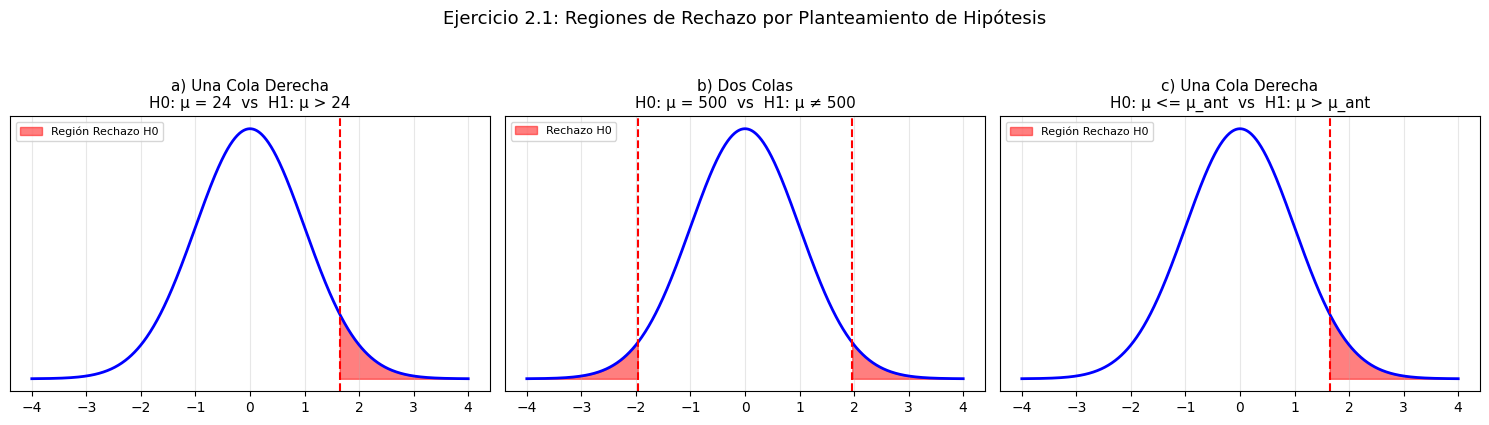

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-4, 4, 1000)
y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Caso A: Cola Derecha (μ > 24)
axes[0].plot(x, y, "b-", lw=2)
axes[0].fill_between(
    x, y, where=(x >= 1.645), color="red", alpha=0.5, label="Región Rechazo H0"
)
axes[0].axvline(1.645, color="red", linestyle="--")
axes[0].set_title("a) Una Cola Derecha\nH0: μ = 24  vs  H1: μ > 24", fontsize=11)
axes[0].set_yticks([])

# Caso B: Dos Colas (μ ≠ 500)
axes[1].plot(x, y, "b-", lw=2)
axes[1].fill_between(
    x, y, where=(x >= 1.96), color="red", alpha=0.5, label="Rechazo H0"
)
axes[1].fill_between(x, y, where=(x <= -1.96), color="red", alpha=0.5)
axes[1].axvline(1.96, color="red", linestyle="--")
axes[1].axvline(-1.96, color="red", linestyle="--")
axes[1].set_title("b) Dos Colas\nH0: μ = 500  vs  H1: μ ≠ 500", fontsize=11)
axes[1].set_yticks([])

# Caso C: Cola Derecha (μ > μ_anterior)
axes[2].plot(x, y, "b-", lw=2)
axes[2].fill_between(
    x, y, where=(x >= 1.645), color="red", alpha=0.5, label="Región Rechazo H0"
)
axes[2].axvline(1.645, color="red", linestyle="--")
axes[2].set_title(
    "c) Una Cola Derecha\nH0: μ <= μ_ant  vs  H1: μ > μ_ant", fontsize=11
)
axes[2].set_yticks([])

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle(
    "Ejercicio 2.1: Regiones de Rechazo por Planteamiento de Hipótesis",
    fontsize=13,
    y=1.05,
)
plt.tight_layout()
plt.show()

## Ejercicio 2.2: Comparación de Valor p vs. Nivel de Significancia ($\alpha$)


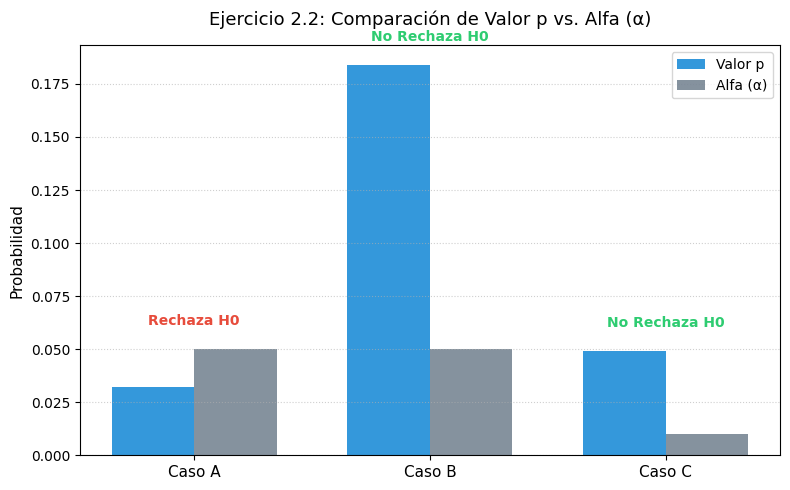

In [5]:
import matplotlib.pyplot as plt
import numpy as np

casos = ["Caso A", "Caso B", "Caso C"]
p_values = [0.032, 0.184, 0.049]
alphas = [0.05, 0.05, 0.01]
decisiones = ["Rechaza H0", "No Rechaza H0", "No Rechaza H0"]
colores = ["#e74c3c", "#2ecc71", "#2ecc71"]

x = np.arange(len(casos))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width / 2, p_values, width, label="Valor p", color="#3498db")
rects2 = ax.bar(
    x + width / 2,
    alphas,
    width,
    label="Alfa (α)",
    color="#34495e",
    alpha=0.6,
)

ax.set_ylabel("Probabilidad", fontsize=11)
ax.set_title(
    "Ejercicio 2.2: Comparación de Valor p vs. Alfa (α)", fontsize=13, pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(casos, fontsize=11)
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.6)

# Etiquetas explicativas sobre las barras
for i in range(len(casos)):
    ax.text(
        x[i],
        max(p_values[i], alphas[i]) + 0.01,
        decisiones[i],
        ha="center",
        va="bottom",
        fontweight="bold",
        color=colores[i],
    )

plt.tight_layout()
plt.show()

## Ejercicio 2.3: Matriz de Matriz de Decisión / Errores Tipo I y Tipo II

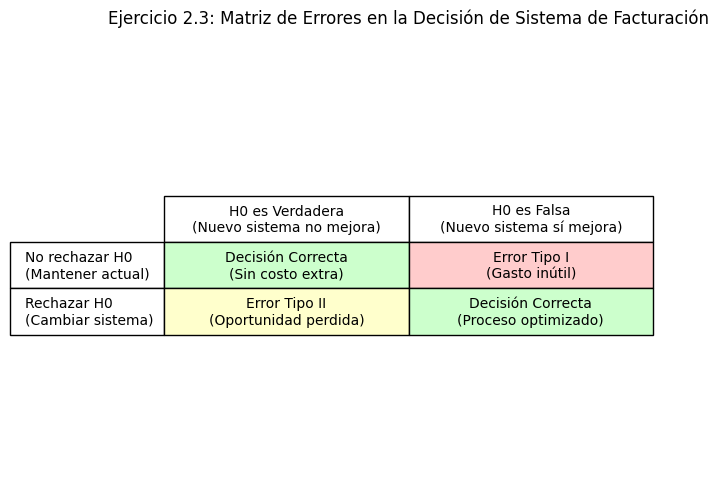

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Crear la matriz
matriz = np.array(
    [
        ["Decisión Correcta\n(Sin costo extra)", "Error Tipo I\n(Gasto inútil)"],
        [
            "Error Tipo II\n(Oportunidad perdida)",
            "Decisión Correcta\n(Proceso optimizado)",
        ],
    ]
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# Tabla visual
tabla = ax.table(
    cellText=matriz,
    rowLabels=[
        "No rechazar H0\n(Mantener actual)",
        "Rechazar H0\n(Cambiar sistema)",
    ],
    colLabels=[
        "H0 es Verdadera\n(Nuevo sistema no mejora)",
        "H0 es Falsa\n(Nuevo sistema sí mejora)",
    ],
    loc="center",
    cellLoc="center",
)

tabla.scale(1.2, 2.5)
tabla.set_fontsize(10)

# Colorear celdas de errores
tabla[(1, 1)].set_facecolor("#ffcccc")  # Error Tipo I
tabla[(2, 0)].set_facecolor("#ffffcc")  # Error Tipo II
tabla[(1, 0)].set_facecolor("#ccffcc")  # Correcto
tabla[(2, 1)].set_facecolor("#ccffcc")  # Correcto

plt.title(
    "Ejercicio 2.3: Matriz de Errores en la Decisión de Sistema de Facturación",
    fontsize=12,
    pad=20,
)
plt.tight_layout()
plt.show()

## Ejercicio 3.1: Diagrama de Selección de Pruebas Estadísticas

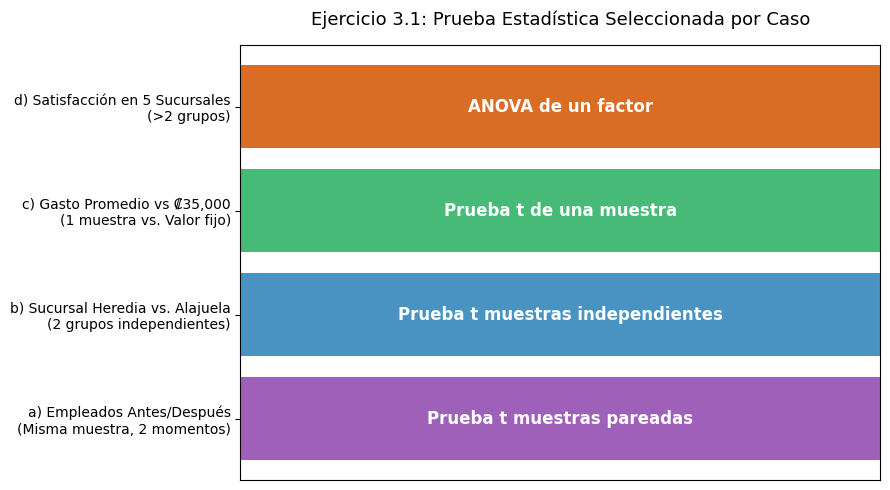

In [7]:
import matplotlib.pyplot as plt

casos = [
    "a) Empleados Antes/Después\n(Misma muestra, 2 momentos)",
    "b) Sucursal Heredia vs. Alajuela\n(2 grupos independientes)",
    "c) Gasto Promedio vs ₡35,000\n(1 muestra vs. Valor fijo)",
    "d) Satisfacción en 5 Sucursales\n(>2 grupos)",
]

pruebas = [
    "Prueba t muestras pareadas",
    "Prueba t muestras independientes",
    "Prueba t de una muestra",
    "ANOVA de un factor",
]

colores = ["#8e44ad", "#2980b9", "#27ae60", "#d35400"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(casos, [1] * 4, color=colores, alpha=0.85)

for i, bar in enumerate(bars):
    ax.text(
        0.5,
        bar.get_y() + bar.get_height() / 2,
        pruebas[i],
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=12,
    )

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title(
    "Ejercicio 3.1: Prueba Estadística Seleccionada por Caso",
    fontsize=13,
    pad=15,
)
ax.grid(False)

plt.tight_layout()
plt.show()

## Ejercicio 3.2: Comparación Muestras Independientes (Tienda Física vs. Línea)

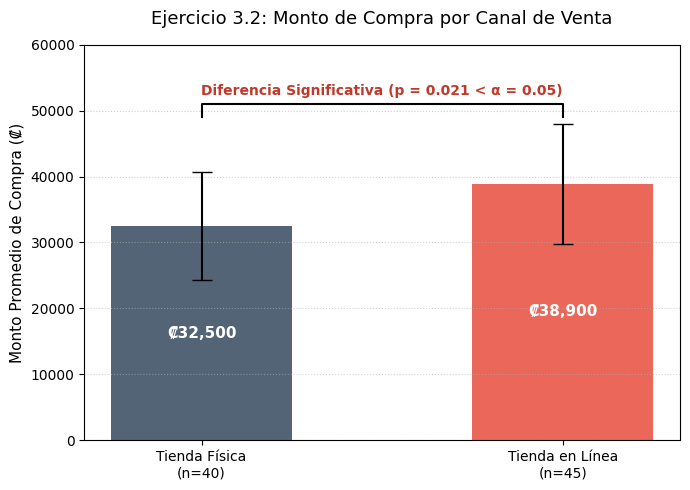

In [8]:
import matplotlib.pyplot as plt
import numpy as np

canales = ["Tienda Física\n(n=40)", "Tienda en Línea\n(n=45)"]
medias = [32500, 38900]
desviaciones = [8200, 9100]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    canales,
    medias,
    yerr=desviaciones,
    capsize=7,
    color=["#34495e", "#e74c3c"],
    alpha=0.85,
    width=0.5,
)

# Etiquetas con los montos
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval / 2,
        f"₡{yval:,.0f}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=11,
    )

# Indicador de diferencia significativa
ax.plot([0, 0, 1, 1], [49000, 51000, 51000, 49000], lw=1.5, color="black")
ax.text(
    0.5,
    52000,
    "Diferencia Significativa (p = 0.021 < α = 0.05)",
    ha="center",
    va="bottom",
    fontweight="bold",
    color="#c0392b",
)

ax.set_ylabel("Monto Promedio de Compra (₡)", fontsize=11)
ax.set_ylim(0, 60000)
ax.set_title(
    "Ejercicio 3.2: Monto de Compra por Canal de Venta",
    fontsize=13,
    pad=15,
)
ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## Ejercicio 3.3: ANOVA entre Turnos y Necesidad de Prueba Post-Hoc

/tmp/ipykernel_1482/1786030012.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_turnos, labels=turnos, patch_artist=True)


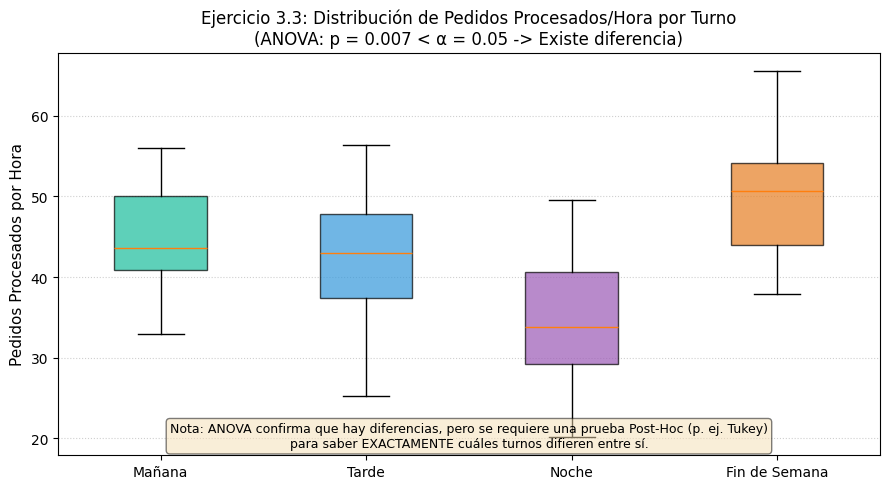

In [9]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

# Simulación de datos para los 4 turnos
manana = np.random.normal(45, 5, 30)
tarde = np.random.normal(42, 6, 30)
noche = np.random.normal(35, 7, 30)
fin_semana = np.random.normal(50, 6, 30)

datos_turnos = [manana, tarde, noche, fin_semana]
turnos = ["Mañana", "Tarde", "Noche", "Fin de Semana"]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(datos_turnos, labels=turnos, patch_artist=True)
colors = ["#1abc9c", "#3498db", "#9b59b6", "#e67e22"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title(
    "Ejercicio 3.3: Distribución de Pedidos Procesados/Hora por Turno\n(ANOVA: p = 0.007 < α = 0.05 -> Existe diferencia)",
    fontsize=12,
)
ax.set_ylabel("Pedidos Procesados por Hora", fontsize=11)
ax.grid(axis="y", linestyle=":", alpha=0.6)

# Nota explicativa sobre Post-Hoc
ax.text(
    0.5,
    0.02,
    "Nota: ANOVA confirma que hay diferencias, pero se requiere una prueba Post-Hoc (p. ej. Tukey)\npara saber EXACTAMENTE cuáles turnos difieren entre sí.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.show()

## Ejercicio 4.1: Significancia Estadística vs. Significancia Práctica

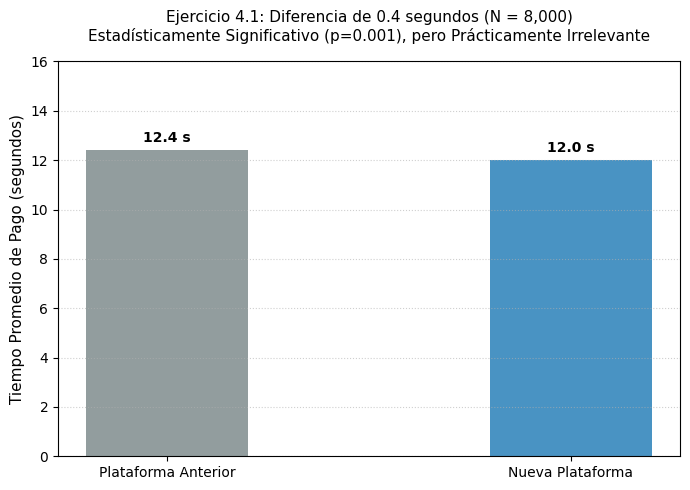

In [10]:
import matplotlib.pyplot as plt

plataformas = ["Plataforma Anterior", "Nueva Plataforma"]
tiempos = [12.4, 12.0]  # Diferencia de 0.4 segundos

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    plataformas, tiempos, color=["#7f8c8d", "#2980b9"], width=0.4, alpha=0.85
)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.2,
        f"{yval:.1f} s",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_ylabel("Tiempo Promedio de Pago (segundos)", fontsize=11)
ax.set_ylim(0, 16)
ax.set_title(
    "Ejercicio 4.1: Diferencia de 0.4 segundos (N = 8,000)\nEstadísticamente Significativo (p=0.001), pero Prácticamente Irrelevante",
    fontsize=11,
    pad=15,
)
ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## Ejercicio 4.2: Interpretación Correcta de Valor p = 0.09

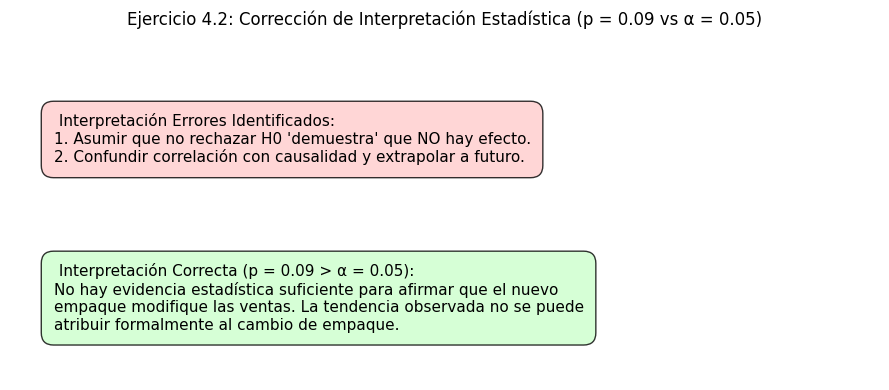

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off")

texto_incorrecto = (
    " Interpretación Errores Identificados:\n"
    "1. Asumir que no rechazar H0 'demuestra' que NO hay efecto.\n"
    "2. Confundir correlación con causalidad y extrapolar a futuro."
)

texto_correcto = (
    " Interpretación Correcta (p = 0.09 > α = 0.05):\n"
    "No hay evidencia estadística suficiente para afirmar que el nuevo\n"
    "empaque modifique las ventas. La tendencia observada no se puede\n"
    "atribuir formalmente al cambio de empaque."
)

ax.text(
    0.05,
    0.65,
    texto_incorrecto,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#ffcccc", alpha=0.8),
)
ax.text(
    0.05,
    0.15,
    texto_correcto,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#ccffcc", alpha=0.8),
)

plt.title(
    "Ejercicio 4.2: Corrección de Interpretación Estadística (p = 0.09 vs α = 0.05)",
    fontsize=12,
    pad=15,
)
plt.tight_layout()
plt.show()

## Ejercicio 4.3: Caso Integrador (Soporte A vs. Soporte B)

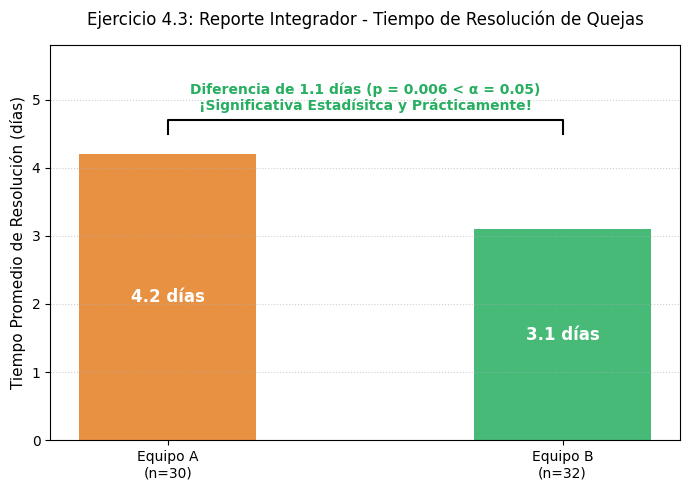

In [13]:
import matplotlib.pyplot as plt

equipos = ["Equipo A\n(n=30)", "Equipo B\n(n=32)"]
tiempos_resolucion = [4.2, 3.1]
colores = ["#e67e22", "#27ae60"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(equipos, tiempos_resolucion, color=colores, width=0.45, alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval / 2,
        f"{yval:.1f} días",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=12,
    )

# Barra de significancia
ax.plot([0, 0, 1, 1], [4.5, 4.7, 4.7, 4.5], lw=1.5, color="black")
ax.text(
    0.5,
    4.8,
    "Diferencia de 1.1 días (p = 0.006 < α = 0.05)\n¡Significativa Estadísitca y Prácticamente!",
    ha="center",
    va="bottom",
    fontweight="bold",
    color="#27ae60",
)

ax.set_ylabel("Tiempo Promedio de Resolución (días)", fontsize=11)
ax.set_ylim(0, 5.8)
ax.set_title(
    "Ejercicio 4.3: Reporte Integrador - Tiempo de Resolución de Quejas",
    fontsize=12,
    pad=15,
)
ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()